   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

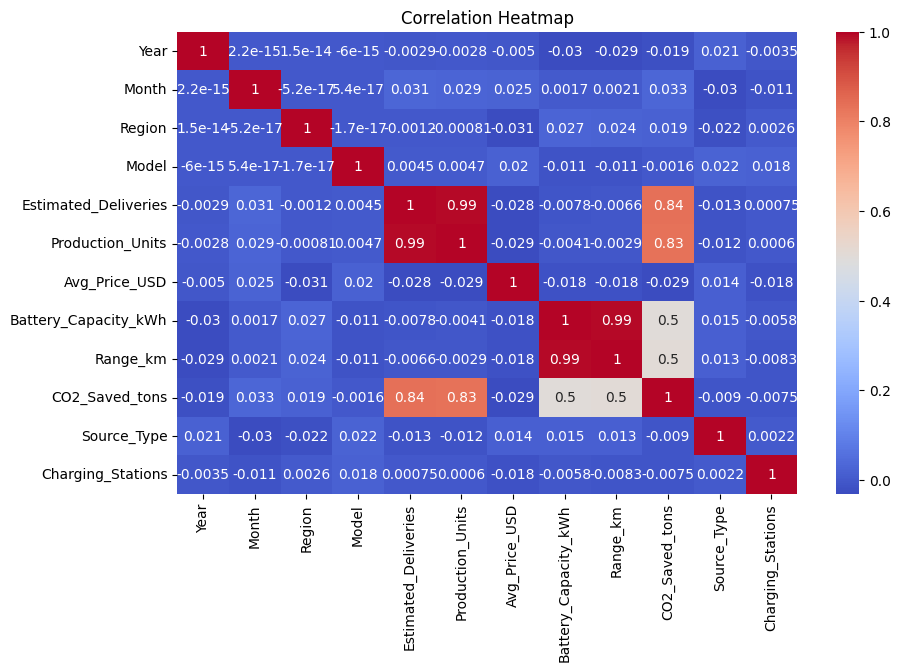

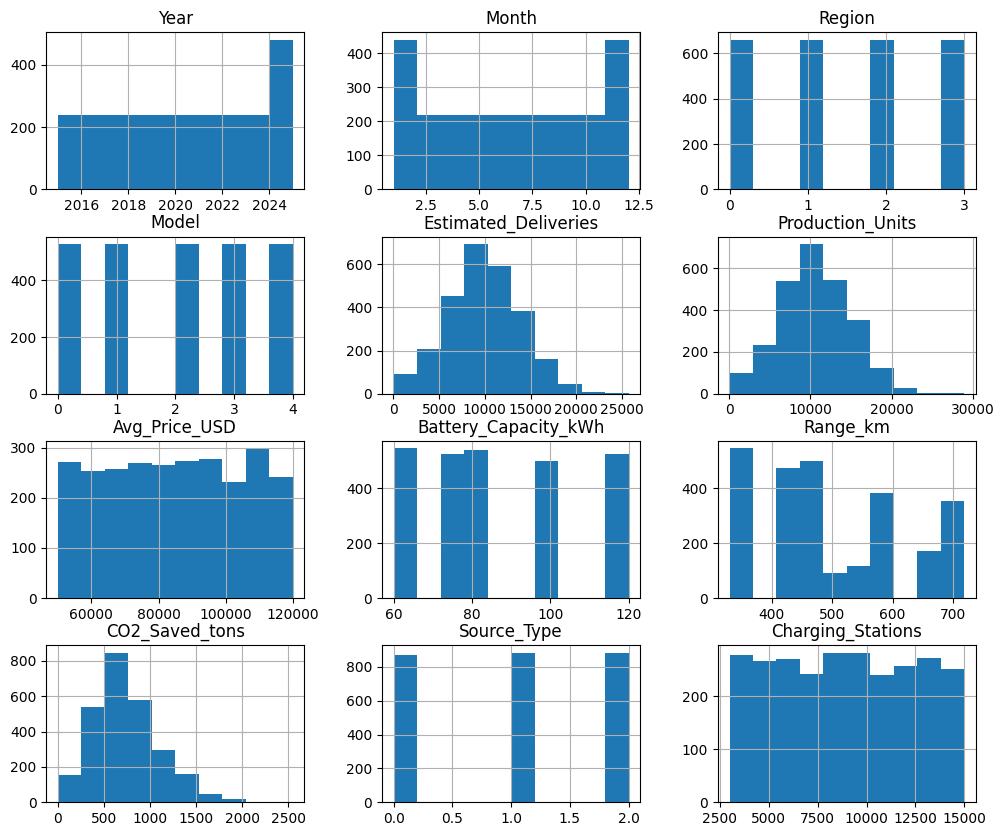

Best Parameters: {'max_depth': 5, 'n_estimators': 50}

Linear Regression Performance
------------------------------
MAE : 2993.190755295732
RMSE: 3473.8248230368126
R2 Score: -0.003386323343022468

Random Forest Performance
------------------------------
MAE : 2994.047528013362
RMSE: 3483.163589041314
R2 Score: -0.008788429600661285

Forecasted Values:
2640    9105.581277
2641    9084.703118
2642    9083.894541
2643    9083.172242
2644    9082.458592
2645    9081.753193
2646    9081.055949
2647    9080.366765
2648    9079.685548
2649    9079.012206
Name: predicted_mean, dtype: float64


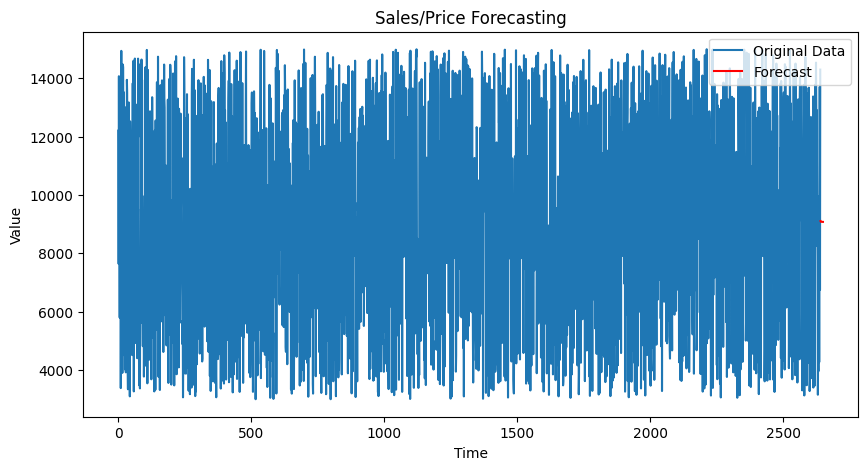

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print(df.head())
print(df.info())

df.dropna(inplace=True)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df.hist(figsize=(12,10))
plt.show()

if 'Date' in df.columns:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

target_column = df.columns[-1]

X = df.drop(columns=[target_column])
y = df[target_column]

if 'Date' in X.columns:
    X = X.drop(columns=['Date'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

rf_model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

rf_pred = best_model.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance")
    print("-"*30)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, rf_pred, "Random Forest")

series = df[target_column]

model = ARIMA(series, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=10)

print("\nForecasted Values:")
print(forecast)

plt.figure(figsize=(10,5))

plt.plot(series.values, label='Original Data')
plt.plot(
    range(len(series), len(series)+10),
    forecast,
    label='Forecast',
    color='red'
)

plt.title("Sales/Price Forecasting")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()